### Tool creation for RAG agents with langgraph 
To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:

- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

#### ✅ Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str

In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

# LLM Model
from langchain_openai import ChatOpenAI

llm = ChatOpenAI()
llm

c:\Users\heman\Desktop\05 Ultimate RAG Bootcamp Using Langchain,LangGraph and Langsmith by Krish Naik\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x00000250D9B478C0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000250D9FDC440>, root_client=<openai.OpenAI object at 0x00000250D9B456A0>, root_async_client=<openai.AsyncOpenAI object at 0x00000250D9FDC1A0>, model_kwargs={}, openai_api_key=SecretStr('**********'))

In [2]:
from langchain_community.document_loaders import TextLoader, ArxivLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain.agents import Tool
from langchain.tools import WikipediaQueryRun
from langchain.utilities import WikipediaAPIWrapper

# **********
# TOOLS
# **********

### Generic function to create a retireval tool
def make_retriever_tool_from_text(file, name, desc):
    docs = TextLoader(file, encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vs.as_retriever()

    def tool_func(query: str) -> str:
        print(f"📚 Using tool: {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(name=name, description=desc, func=tool_func)


# Wikipedia Tool
wiki_tool = Tool(
    name = "Wikipedia",
    description =  "Use this tool to fetch general world knowledge from Wikipedia.",
    func = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
)

# ArXiv Tool
def arxiv_search(query: str) -> str:
    print("🧪 Searching ArXiv...")
    results = ArxivLoader(query).load()
    return "\n\n".join(doc.page_content[:1000] for doc in results[:2]) or "No papers found."

arxiv_tool = Tool(
    name = "ArxivSearch",
    description = "Use this tool to fetch recent academic papers on technical topics.",
    func = arxiv_search
)


In [3]:
# Internal Tech Docs
internal_tool_1 = make_retriever_tool_from_text(
    "internal-docs.txt",
    "InternalTechDocs",
    "Search internal tech documents for proprietary architecture and methods."
)

internal_tool_1

Tool(name='InternalTechDocs', description='Search internal tech documents for proprietary architecture and methods.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x00000250B8488220>)

In [4]:
internal_tool_2 = make_retriever_tool_from_text(
    "research-notes.txt",
    "InternalTechDocs",
    "Search internal research notes for experimental results and agent designs."
)

internal_tool_2

Tool(name='InternalTechDocs', description='Search internal research notes for experimental results and agent designs.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x00000251057F32E0>)

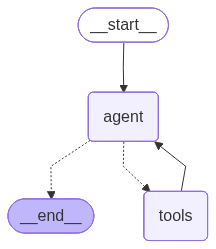

In [5]:
from langgraph.prebuilt import create_react_agent

# List of tools
tools=[wiki_tool, arxiv_tool, internal_tool_1, internal_tool_2]

react_node = create_react_agent(llm, tools)
react_node

In [6]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

# State
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

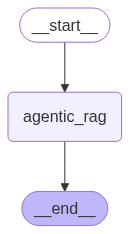

In [7]:
from langgraph.graph import StateGraph, START, END 

# Build the graph
graph = StateGraph(AgentState)

# Node
graph.add_node("agentic_rag", react_node)

# Edges
graph.add_edge(START, "agentic_rag")
graph.add_edge("agentic_rag", END)

# Compile
workflow = graph.compile()
workflow

In [10]:
from langchain_core.messages import HumanMessage

query = "What do our internal research notes say about transformer variants, and what does ArXiv suggest recently?"

state = {"messages": [HumanMessage(content=query)]}
result = workflow.invoke(state)

print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using tool: InternalTechDocs
🧪 Searching ArXiv...

✅ Final Answer:
 ### Internal Research Notes on Transformer Variants:

#### EfficientFormer:
- Top-1 accuracy: 92.4% on TinyImageNet
- Peak memory usage: 290MB (batch size = 16)
- Deployment target: Raspberry Pi 4
- Notes: Works well in quantized int8 mode with no major accuracy drop

#### Longformer:
- Evaluation on customer support logs (max tokens: 8192)
- Latency >1.2s per query in streaming setting
- Observations: Chunk-based hybrid attention may reduce delay

#### Reformer:
- Challenges during training:
  - Bucket collisions
  - Inconsistent loss spikes beyond 5k steps
  - Sparse gradient updates during LSH attention
- Solutions tried:
  - Gradient clipping
  - Warmup scheduler
  - Memory-efficient attention modules

#### TinyBERT:
- Used for classification: Support ticket priority tagging
- Evaluation: 87% F1 score, confusion in ambiguous class C
- Works well with 2-layer FFN adapter for domain transfer

#### Additional Experi